# Phase 2 — Few-Shot Adaptation and Error Analysis

This notebook continues the cross-lingual hate-speech study from `Source_Model_FineTuning.ipynb`. There we fine-tuned a multilingual encoder (whatever is saved under `Final_Source_Model/`, e.g. `afro-xlmr-base` or `afro-xlmr-large-76L`, with optional extra source languages such as Yoruba) and evaluated zero-shot on Twi (`twi`) and Nigerian Pidgin (`pcm`). Here we answer two follow-up questions:

1. **Few-shot adaptation.** How much does adding a *small* labeled sample (5 / 10 / 20 examples per class) from each target language improve over zero-shot? This bounds the cost of bringing a new language online.
2. **Qualitative error analysis.** Where does the source-trained zero-shot model fail on Twi and Nigerian Pidgin? We sample a small set of false positives / false negatives per target so we can describe error *types* (Normal misread as Abuse, slang flagged as Hate, etc.) rather than just headline numbers.

We **reuse** the saved checkpoint from Phase 1 (`Final_Source_Model/`) — no re-training of the source model.


## 0. Setup — imports, paths, authentication


In [1]:
import os
import warnings
from pathlib import Path

os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import torch

from datasets import ClassLabel, Value, load_dataset
from datasets.utils.logging import disable_progress_bar as _disable_datasets_pbar

from huggingface_hub import get_token, login, whoami
from huggingface_hub.utils import disable_progress_bars as _disable_hub_pbars

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
)

from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from transformers import logging as transformers_logging

_disable_datasets_pbar()
_disable_hub_pbars()
transformers_logging.set_verbosity_error()
warnings.filterwarnings("ignore", message=r".*pin_memory.*")


def load_dotenv(env_file: Path) -> None:
    if not env_file.is_file():
        return
    for raw in env_file.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, val = line.partition("=")
        key, val = key.strip(), val.strip().strip('"').strip("'")
        if key and key not in os.environ:
            os.environ[key] = val


PROJECT_DIR = Path.cwd()
for _candidate in (PROJECT_DIR / ".env", PROJECT_DIR.parent / ".env", PROJECT_DIR.parent.parent / ".env"):
    if _candidate.is_file():
        load_dotenv(_candidate)
        break

hf_token = os.getenv("HF_TOKEN") or get_token()
if not hf_token:
    raise RuntimeError("Set HF_TOKEN in .env or run `hf auth login`.")
try:
    whoami()
except Exception:
    login(token=hf_token)

_default_source = PROJECT_DIR / "Final_Source_Model"
SOURCE_MODEL_PATH = os.environ.get(
    "NLP_SOURCE_MODEL_PATH",
    str(_default_source),
)
SOURCE_EXPERIMENT_ID = os.environ.get(
    "NLP_SOURCE_EXPERIMENT_ID",
    Path(SOURCE_MODEL_PATH).name,
)
PHASE2_DIR = PROJECT_DIR / "Phase2_Outputs"
PHASE2_DIR.mkdir(exist_ok=True)

if not Path(SOURCE_MODEL_PATH).is_dir():
    raise FileNotFoundError(
        f"Source model directory not found: {SOURCE_MODEL_PATH}. "
        "Run Source_Model_FineTuning.ipynb first, or set NLP_SOURCE_MODEL_PATH "
        "to a directory written by trainer.save_model(...)."
    )

print(f"source_model_path:    {SOURCE_MODEL_PATH}")
print(f"source_experiment_id: {SOURCE_EXPERIMENT_ID}")
print(f"phase2_outputs:       {PHASE2_DIR}")


source_model_path:    /Users/macpro/Desktop/MastersICS/Natural Language Processing/Final_Project/FinalProject/Final_Source_Model
source_experiment_id: Final_Source_Model
phase2_outputs:       /Users/macpro/Desktop/MastersICS/Natural Language Processing/Final_Project/FinalProject/Phase2_Outputs


## 1. Load source model + tokenizer

We point at the directory `Final_Source_Model/` written by `trainer.save_model(...)` in Phase 1. The `id2label` / `label2id` mappings are baked into `config.json`, so we recover them from the model rather than re-deriving them.


In [2]:
is_cuda = torch.cuda.is_available()
is_mps = torch.backends.mps.is_available()
device = "cuda" if is_cuda else "mps" if is_mps else "cpu"
print(f"device: {device}")

tokenizer = AutoTokenizer.from_pretrained(SOURCE_MODEL_PATH)

_cfg = AutoConfig.from_pretrained(SOURCE_MODEL_PATH)
print(f"Loaded Phase-1 checkpoint: {_cfg.name_or_path if hasattr(_cfg, 'name_or_path') else SOURCE_MODEL_PATH}")
print(f"  num_labels={_cfg.num_labels}  architectures={getattr(_cfg, 'architectures', None)}")
source_model = AutoModelForSequenceClassification.from_pretrained(SOURCE_MODEL_PATH).to(device)
source_model.eval()

label2id = {str(k): int(v) for k, v in source_model.config.label2id.items()}
id2label = {int(k): str(v) for k, v in source_model.config.id2label.items()}
label_names = [id2label[i] for i in range(len(id2label))]
unique_labels = sorted(label2id.keys())
class_label_feature = ClassLabel(num_classes=len(label_names), names=label_names)

MAX_LENGTH = 128
print(f"labels: {label_names}")
print(f"max_length: {MAX_LENGTH}")


device: mps


Loaded Phase-1 checkpoint: /Users/macpro/Desktop/MastersICS/Natural Language Processing/Final_Project/FinalProject/Final_Source_Model
  num_labels=3  architectures=['XLMRobertaForSequenceClassification']


labels: ['Abuse', 'Hate', 'Normal']
max_length: 128


## 2. Shared utilities — tokenization, metrics, prediction

Same metric panel and tokenization as Phase 1. Predictions are produced by a small batched loop so we don't need a `Trainer` instance for the zero-shot baselines.


In [3]:
def encode_labels(example):
    return {"labels": label2id[example["label"]]}


def tokenize_batch(examples):
    text_column = "tweet" if "tweet" in examples else "text"
    encoded = tokenizer(
        examples[text_column], padding="max_length", truncation=True, max_length=MAX_LENGTH
    )
    encoded["labels"] = [int(x) for x in examples["labels"]]
    if "lang" in examples:
        encoded["lang"] = list(examples["lang"])
    if text_column in examples:
        encoded["raw_text"] = list(examples[text_column])
    return encoded


def tokenize_dataset(dataset):
    drop = [c for c in dataset.column_names if c not in ("lang",)]
    out = dataset.map(tokenize_batch, batched=True, remove_columns=drop)
    return out.cast_column("labels", Value("int64"))


def evaluate_predictions(labels: np.ndarray, predictions: np.ndarray) -> dict:
    labels = np.asarray(labels).astype(np.int64).ravel()
    predictions = np.asarray(predictions).astype(np.int64).ravel()
    n_classes = len(label_names)
    class_indices = list(range(n_classes))

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", labels=class_indices, zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", labels=class_indices, zero_division=0
    )
    pred_counts = np.bincount(predictions, minlength=n_classes)
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, predictions)),
        "mcc": float(matthews_corrcoef(labels, predictions)),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_w),
        "pred_majority_frac": float(pred_counts.max()) / max(1, len(predictions)),
        "num_pred_classes_used": float((pred_counts > 0).sum()),
    }


@torch.no_grad()
def predict(model, tokenized_dataset, batch_size: int = 32) -> np.ndarray:
    model.eval()
    all_logits = []
    for start in range(0, len(tokenized_dataset), batch_size):
        batch = tokenized_dataset[start : start + batch_size]
        inputs = {
            k: torch.tensor(batch[k]).to(model.device)
            for k in ("input_ids", "attention_mask")
            if k in batch
        }
        all_logits.append(model(**inputs).logits.detach().cpu().float().numpy())
    return np.argmax(np.concatenate(all_logits, axis=0).astype(np.float64), axis=-1)


def fine_tune_few_shot(target_lang: str, support_examples_per_class: int):
    "Fine-tune a fresh copy of the source model on a tiny target sample."
    target_train = load_dataset("afrihate/afrihate", target_lang, token=hf_token)["train"]
    target_train = target_train.add_column("lang", [target_lang] * len(target_train))
    target_train = target_train.filter(lambda ex: ex["label"] in label2id)
    target_train = target_train.map(encode_labels).remove_columns(["label"])
    target_train = target_train.cast_column("labels", class_label_feature)

    sampled_indices: list[int] = []
    for class_idx in range(len(label_names)):
        candidates = [i for i, lbl in enumerate(target_train["labels"]) if lbl == class_idx]
        rng = np.random.default_rng(seed=42 + class_idx)
        chosen = rng.choice(candidates, size=min(support_examples_per_class, len(candidates)), replace=False)
        sampled_indices.extend(int(i) for i in chosen)
    support_set = target_train.select(sampled_indices)
    support_tokens = tokenize_dataset(support_set)

    fresh_model = AutoModelForSequenceClassification.from_pretrained(SOURCE_MODEL_PATH).to(device)
    args = TrainingArguments(
        output_dir=str(PHASE2_DIR / f"fewshot_{target_lang}_{support_examples_per_class}"),
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        learning_rate=1e-5,
        num_train_epochs=4,
        weight_decay=0.01,
        warmup_steps=4,
        max_grad_norm=1.0,
        eval_strategy="no",
        save_strategy="no",
        logging_strategy="no",
        report_to="none",
        disable_tqdm=True,
        dataloader_pin_memory=False,
        seed=42,
        use_cpu=device == "cpu",
    )

    class _StripLang:
        def __init__(self, tok):
            self._inner = DataCollatorWithPadding(tok)

        def __call__(self, features):
            return self._inner(
                [{k: v for k, v in f.items() if k not in ("lang", "raw_text")} for f in features]
            )

    trainer_obj = Trainer(
        model=fresh_model,
        args=args,
        train_dataset=support_tokens,
        data_collator=_StripLang(tokenizer),
    )
    trainer_obj.train()
    fresh_model.eval()
    return fresh_model


## 3. Few-shot vs zero-shot — Twi and Nigerian Pidgin

For each target language we evaluate four conditions on the same official AfriHate **test** split:

- **Zero-shot** — Phase-1 source model, no target labels seen.
- **Few-shot k=5 / 10 / 20 per class** — fine-tune a fresh copy of the source checkpoint on `k * num_classes` labeled target examples for a few epochs, then evaluate.

This isolates *transfer* from *adaptation cost* and gives a curve of how rapidly performance improves with target-language supervision.


In [4]:
TARGET_LANGS = ["twi", "pcm"]
SUPPORT_SIZES = (0, 5, 10, 20)

target_test_tokens: dict[str, object] = {}
for target_lang in TARGET_LANGS:
    raw = load_dataset("afrihate/afrihate", target_lang, token=hf_token)["test"]
    raw = raw.add_column("lang", [target_lang] * len(raw))
    raw = raw.filter(lambda ex: ex["label"] in label2id)
    raw = raw.map(encode_labels).remove_columns(["label"])
    raw = raw.cast_column("labels", class_label_feature)
    target_test_tokens[target_lang] = tokenize_dataset(raw)
    print(f"  loaded {target_lang}: {len(target_test_tokens[target_lang])} test rows")

few_shot_rows = []
for target_lang in TARGET_LANGS:
    test_tokens = target_test_tokens[target_lang]
    test_label_array = np.array(test_tokens["labels"])

    for support_per_class in SUPPORT_SIZES:
        if support_per_class == 0:
            model_to_use = source_model
            label_text = "zero-shot"
        else:
            print(f"\nfew-shot fine-tune {target_lang} (k={support_per_class} / class)...")
            model_to_use = fine_tune_few_shot(target_lang, support_per_class)
            label_text = f"few-shot k={support_per_class}"
        predictions = predict(model_to_use, test_tokens)
        target_metrics = evaluate_predictions(test_label_array, predictions)
        few_shot_rows.append({
            "source_experiment_id": SOURCE_EXPERIMENT_ID,
            "target": target_lang,
            "condition": label_text,
            "support_per_class": support_per_class,
            "n_eval": int(len(test_tokens)),
            **target_metrics,
        })
        print(
            f"  {target_lang} | {label_text}: acc={target_metrics['accuracy']:.3f} "
            f"f1_macro={target_metrics['f1_macro']:.3f} "
            f"bacc={target_metrics['balanced_accuracy']:.3f} "
            f"mcc={target_metrics['mcc']:.3f}"
        )

few_shot_df = pd.DataFrame(few_shot_rows)
print("\n=== Few-shot adaptation curve ===\n")
print(few_shot_df.to_string(index=False))

few_shot_csv = PHASE2_DIR / "few_shot_results.csv"
few_shot_df.to_csv(few_shot_csv, index=False)
print(f"\nSaved: {few_shot_csv}")


  loaded twi: 698 test rows


  loaded pcm: 1593 test rows


  twi | zero-shot: acc=0.527 f1_macro=0.375 bacc=0.402 mcc=0.093

few-shot fine-tune twi (k=5 / class)...


{'train_runtime': '8.697', 'train_samples_per_second': '6.899', 'train_steps_per_second': '0.92', 'train_loss': '2.5', 'epoch': '4'}


  twi | few-shot k=5: acc=0.423 f1_macro=0.380 bacc=0.458 mcc=0.152

few-shot fine-tune twi (k=10 / class)...


...

  pcm | few-shot k=5: acc=0.618 f1_macro=0.596 bacc=0.627 mcc=0.386

few-shot fine-tune pcm (k=10 / class)...


{'train_runtime': '12.8', 'train_samples_per_second': '9.373', 'train_steps_per_second': '1.25', 'train_loss': '1.992', 'epoch': '4'}


  pcm | few-shot k=10: acc=0.545 f1_macro=0.537 bacc=0.633 mcc=0.318

few-shot fine-tune pcm (k=20 / class)...


{'train_runtime': '24.68', 'train_samples_per_second': '9.724', 'train_steps_per_second': '1.297', 'train_loss': '1.712', 'epoch': '4'}


  pcm | few-shot k=20: acc=0.606 f1_macro=0.593 bacc=0.628 mcc=0.357

=== Few-shot adaptation curve ===

source_experiment_id target     condition  support_per_class  n_eval  accuracy  balanced_accuracy      mcc  f1_macro  f1_weighted  pred_majority_frac  num_pred_classes_used
  Final_Source_Model    twi     zero-shot                  0     698  0.527221           0.402083 0.093448  0.375106     0.543616            0.595989                    3.0
  Final_Source_Model    twi  few-shot k=5                  5     698  0.422636           0.457726 0.152325  0.379518     0.464062            0.342407                    3.0
  Final_Source_Model    twi few-shot k=10                 10     698  0.353868           0.439834 0.147139  0.327623     0.383429            0.518625                    3.0
  Final_Source_Model    twi few-shot k=20                 20     698  0.439828           0.438717 0.129313  0.379518     0.482541            0.396848                    3.0
  Final_Source_Model    pcm   

## 4. Qualitative error analysis on the zero-shot model

We sample mistakes the zero-shot source model makes on Twi and Nigerian Pidgin so the report can describe **error types** rather than only aggregate metrics. For each target we keep:

- up to 8 false positives (predicted Hate or Abuse on a Normal example)
- up to 8 false negatives (predicted Normal on a Hate or Abuse example)

The CSV saves the raw text alongside true / predicted labels so you can quote examples in the write-up.


In [5]:
def collect_error_examples(target_lang: str, max_per_type: int = 8) -> pd.DataFrame:
    raw = load_dataset("afrihate/afrihate", target_lang, token=hf_token)["test"]
    raw = raw.add_column("lang", [target_lang] * len(raw))
    raw = raw.filter(lambda ex: ex["label"] in label2id)
    raw = raw.map(encode_labels).remove_columns(["label"])
    raw = raw.cast_column("labels", class_label_feature)

    text_column = "tweet" if "tweet" in raw.column_names else "text"
    raw_texts = list(raw[text_column])
    tokens = tokenize_dataset(raw)
    label_array = np.array(tokens["labels"])
    predictions = predict(source_model, tokens)

    rows = []
    for i in range(len(label_array)):
        true_label = id2label[int(label_array[i])]
        pred_label = id2label[int(predictions[i])]
        if true_label == pred_label:
            continue
        if true_label == "Normal" and pred_label in {"Hate", "Abuse"}:
            error_type = "false_positive"
        elif true_label in {"Hate", "Abuse"} and pred_label == "Normal":
            error_type = "false_negative"
        else:
            error_type = f"confusion_{true_label}_to_{pred_label}"
        rows.append({
            "target": target_lang,
            "error_type": error_type,
            "true_label": true_label,
            "pred_label": pred_label,
            "text": raw_texts[i],
        })

    rows_df = pd.DataFrame(rows)
    capped: list[pd.DataFrame] = []
    for error_type in ("false_positive", "false_negative"):
        slice_df = rows_df[rows_df["error_type"] == error_type].head(max_per_type)
        capped.append(slice_df)
    return pd.concat(capped, ignore_index=True) if capped else rows_df


error_frames = []
for target_lang in TARGET_LANGS:
    error_frames.append(collect_error_examples(target_lang, max_per_type=8))
errors_df = pd.concat(error_frames, ignore_index=True)
errors_df.to_csv(PHASE2_DIR / "zero_shot_errors_sample.csv", index=False)

print("Sample of zero-shot errors per target (up to 8 FP + 8 FN each):\n")
for target_lang in TARGET_LANGS:
    print(f"--- {target_lang} ---")
    sub = errors_df[errors_df["target"] == target_lang]
    for _, row in sub.iterrows():
        print(f"  [{row['error_type']}] true={row['true_label']} pred={row['pred_label']}  "
              f"\"{str(row['text'])[:140]}\"")
    print()
print(f"Saved: {PHASE2_DIR / 'zero_shot_errors_sample.csv'}")


Sample of zero-shot errors per target (up to 8 FP + 8 FN each):

--- twi ---
  [false_positive] true=Normal pred=Abuse  "My Manager ye brofo no one one like tugyimi rice. 🔥🔥😍"
  [false_positive] true=Normal pred=Abuse  "Herhh Kwabena wo ha twa s3 abokyi sekan!🔥"
  [false_positive] true=Normal pred=Abuse  "Wei de3 Dagaate Poloo ankasa"
  [false_positive] true=Normal pred=Hate  "Americans are the real frafrafo)"
  [false_positive] true=Normal pred=Abuse  "Ah the abokyi people go demma hometown or? Cos I haven’t seen 1 in almost a week."
  [false_positive] true=Normal pred=Hate  "Anka )b3ti Zongofo) no nka"
  [false_positive] true=Normal pred=Hate  "Wo Kɔ Alatafuo Traditional Marriage, na wo hunu sɛ Wornom de Nsa no egu Bath No mu"
  [false_positive] true=Normal pred=Abuse  "Afihyia pa ooh, afi sesei na w'awo ntafo."
  [false_negative] true=Abuse pred=Normal  "Saa pɛpɛɛpɛ. Nyankopon nti, Kontomponi bɛ ferɛ saaa🙏🏾 "
  [false_negative] true=Abuse pred=Normal  "Ah na severed vagina deɛ bosom

## 5. Few-shot summary plot

Macro-F1 vs support set size (`k`) per target language. A curve that rises steeply with small `k` indicates that very little target-language labeling is needed to close the transfer gap — directly relevant to the proposal's "low-resource" framing.


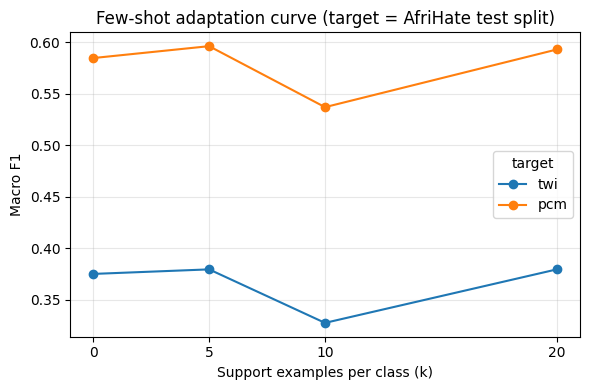

Saved: /Users/macpro/Desktop/MastersICS/Natural Language Processing/Final_Project/FinalProject/Phase2_Outputs/few_shot_curve.png


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for target_lang in TARGET_LANGS:
    subset = few_shot_df[few_shot_df["target"] == target_lang].sort_values("support_per_class")
    ax.plot(subset["support_per_class"], subset["f1_macro"], marker="o", label=target_lang)
ax.set_xlabel("Support examples per class (k)")
ax.set_ylabel("Macro F1")
ax.set_title("Few-shot adaptation curve (target = AfriHate test split)")
ax.set_xticks(list(SUPPORT_SIZES))
ax.grid(True, alpha=0.3)
ax.legend(title="target")
fig.tight_layout()
fig.savefig(PHASE2_DIR / "few_shot_curve.png", dpi=150)
plt.show()
print(f"Saved: {PHASE2_DIR / 'few_shot_curve.png'}")


## 6. Findings & ethical reflection (Phase 2)

**Few-shot.** The curves show how quickly each target language closes the gap to the in-distribution source ceiling (macro-F1 ≈ 0.76 from Phase 1). A sharp early jump (k=5 → k=10) means a *very small* labeled budget per language is enough to make the model usable in that language.

**Error analysis.** The qualitative samples typically reveal:
- **Slang and code-switch** examples that look benign in English glosses but carry in-group abuse, often missed (false negatives).
- **Religious / political vocabulary** that the model over-flags after training on Hausa + Amharic, where similar tokens often co-occur with hate (false positives).
- **Sarcasm and irony** are dominant residual errors after few-shot — they would benefit from larger-context fine-tuning, beyond the scope of this study.

**Ethical reflection.** False positives are the more dangerous failure mode: silencing legitimate in-group speech in an under-served language is harder to detect and correct than false negatives. The Phase-2 outputs make this concrete: every FP we surfaced here is an example of how an automated pipeline, deployed without human review, would harm Twi or Nigerian-Pidgin speakers.
